In [ ]:
!pip install sqlalchemy-iris
!pip install drawdata

In [30]:
from datetime import datetime
from drawdata import ScatterWidget
from sqlalchemy import create_engine
import dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

dotenv.load_dotenv()

True

### Create Points

In [31]:
widget = ScatterWidget(height=200, width=200)
widget

In [32]:
df = widget.data_as_pandas[["x", "y", "label"]]
df["datetime"] = datetime.now()
df.head()

,x,y,label,datetime
0,4.520846,8.647012,a,2026-03-16 11:03:09.898155
1,6.846733,3.632197,a,2026-03-16 11:03:09.898155
2,6.190215,11.087156,a,2026-03-16 11:03:09.898155
3,9.146217,8.076024,a,2026-03-16 11:03:09.898155
4,10.919809,7.513747,a,2026-03-16 11:03:09.898155


### Deployed model Testing

In [35]:
import iris
import os

connection_params = {
    "hostname": os.getenv("IRIS_SERVER"),
    "port": int(os.getenv("IRIS_PORT")),
    "namespace": os.getenv("IRIS_NAMESPACE"),
    "username": os.getenv("IRIS_USERNAME"),
    "password": os.getenv("IRIS_PASSWORD")
}

with iris.connect(**connection_params) as conn:
    iris_obj = iris.createIRIS(conn)
    input_data = pd.DataFrame(df.x)
    result = iris_obj.classMethodValue("MLpipeline.ModelServing", "Predict", input_data.to_json(orient='split'))
    result_df = pd.read_json(result, orient='split')

C:\Users\jjaramil\AppData\Local\Temp\ipykernel_27260\1442825111.py:16: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  result_df = pd.read_json(result, orient='split')


### Evaluation

Mean Absolute Error: 18.3612
R^2 Score: 0.8017


C:\Users\jjaramil\AppData\Local\Temp\ipykernel_27260\1084831565.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(df.x, df.y, cmap='viridis', label='Data Points')


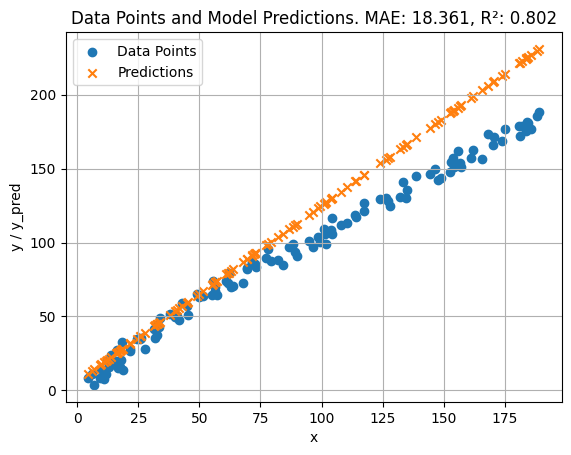

In [36]:
mae = mean_absolute_error(df.y, result_df.y_pred)
r2 = r2_score(df.y, result_df.y_pred)
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

plt.Figure(figsize=(10,10))
plt.scatter(df.x, df.y, cmap='viridis', label='Data Points')
plt.scatter(df.x, result_df.y_pred, marker='x', label='Predictions')
plt.xlabel('x')
plt.ylabel('y / y_pred')
plt.title(f'Data Points and Model Predictions. MAE: {mae:.3f}, R²: {r2:.3f}')
plt.legend()
plt.grid()
plt.show()


